In [189]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import ast
import ipywidgets as widgets
from IPython.display import display, clear_output

In [ ]:
csv = pd.read_csv('director_list.csv')

def loading_data(csv):
    data = csv.copy()


    results = []

    for i in range(len(data)):

        df = pd.read_csv(f"director_{i}.csv")

        # sort movies by year
        df = df.sort_values('release_year')
        # latest movie
        latest = df.iloc[-1]

        # historical movies
        historical = df.iloc[:-1]

        # Calculating overall mean score of the different factors for all movies before the last one 
        hist_avg_score = historical["avg_score"].mean()
        hist_avg_roi  = (historical['revenue'] / historical['budget']).mean()
        hist_avg_revenue = historical['revenue'].mean()
        hist_votes = historical['imdb_vote_count'].sum()

        # Getting the scores for the latest movie
        new_score = latest['avg_score']
        new_roi = latest['revenue']/latest['budget']
        new_revenue = latest['revenue']
        new_votes = latest['imdb_vote_count']

        # Adding entry to result dictionary for each director
        results.append({
            'director' : data['name'][i],
            'hist_avg_score' : hist_avg_score,
            'hist_avg_roi' : hist_avg_roi,
            'hist_avg_revenue' : hist_avg_revenue,
            'hist_total_votes' : hist_votes,
            'new_score' : new_score,
            'new_roi' : new_roi,
            'new_revenue' : new_revenue,
            'new_votes' : new_votes 
        })

    analysis_df = pd.DataFrame(results)

    corr = analysis_df.corr(numeric_only=True)

    return analysis_df

    id  director_id                  title     budget     revenue  \
4    4            0              Following       6000      126052   
8    8            0                Memento    9000000    40060108   
7    7            0               Insomnia   46000000   113714830   
6    6            0          Batman Begins  150000000   374218673   
9    9            0           The Prestige   40000000   109676311   
10  10            0        The Dark Knight  185000000  1004558444   
5    5            0              Inception  160000000   839030630   
11  11            0  The Dark Knight Rises  250000000  1081041287   
3    3            0           Interstellar  165000000   746606706   
1    1            0                Dunkirk  150000000   527000000   
2    2            0                  Tenet  205000000   365304105   
0    0            0            Oppenheimer  100000000   952000000   

    release_year  avg_score  imdb_vote_count  
4           1999       7.18           109420  
8       

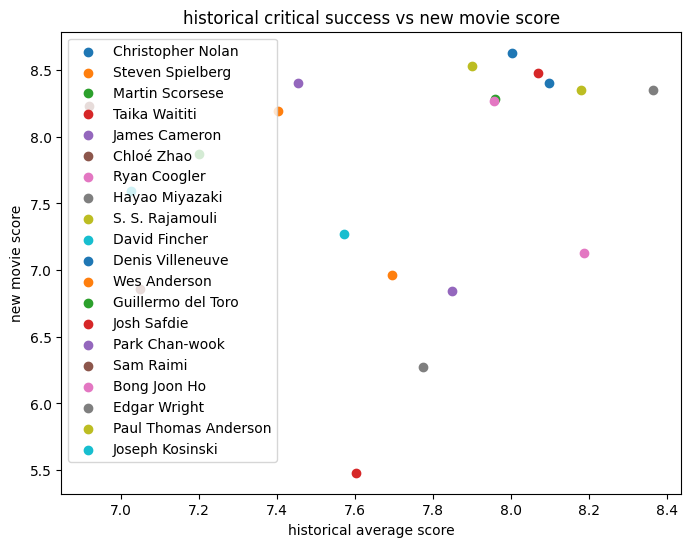

In [ ]:
def avg_score_scatter(data):
    data = loading_data(data)

    # Setting size of the graph
    plt.figure(figsize=(8,6))

    # Going through result director list
    for i, director in enumerate(data['director']):
        # Plotting the average_score comparison for each director
        plt.scatter(data['hist_avg_score'][i], data['new_score'][i],
                    marker='o',
                    label=director

                    )
        plt.text(
            data['hist_avg_score'][i],
            data['new_score'][i],
            ""
        )

    plt.xlabel('historical average score')
    plt.ylabel('new movie score')
    plt.title('historical critical success vs new movie score')

    plt.legend()
    
    plt.show()

avg_score_scatter(csv)

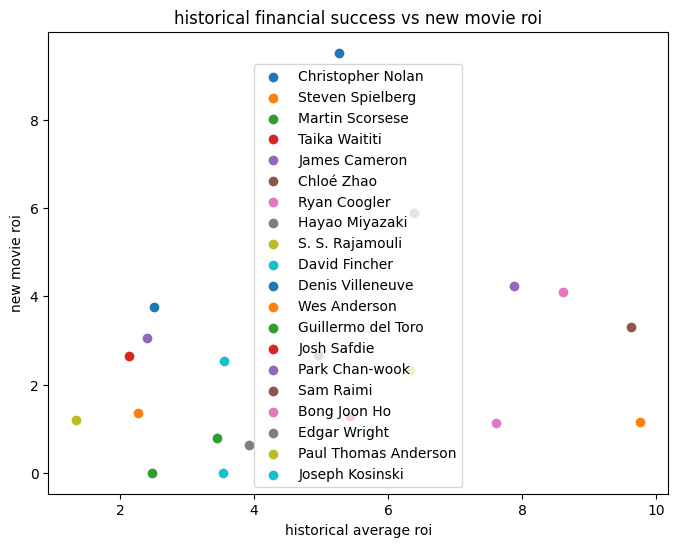

In [268]:
def financial_success_scatter(csv):
    data = loading_data(csv)
    plt.figure(figsize=(8,6))

    for i, director in enumerate(data['director']):
        

        plt.scatter(data['hist_avg_roi'][i], data['new_roi'][i],
                    marker='o',
                    label=director
                    )
        plt.text(
            data['hist_avg_roi'][i],
            data['new_roi'][i],
            ""
        )

    plt.xlabel('historical average roi')
    plt.ylabel('new movie roi')
    plt.title('historical financial success vs new movie roi')
    plt.legend()
    plt.show()

financial_success_scatter(csv)

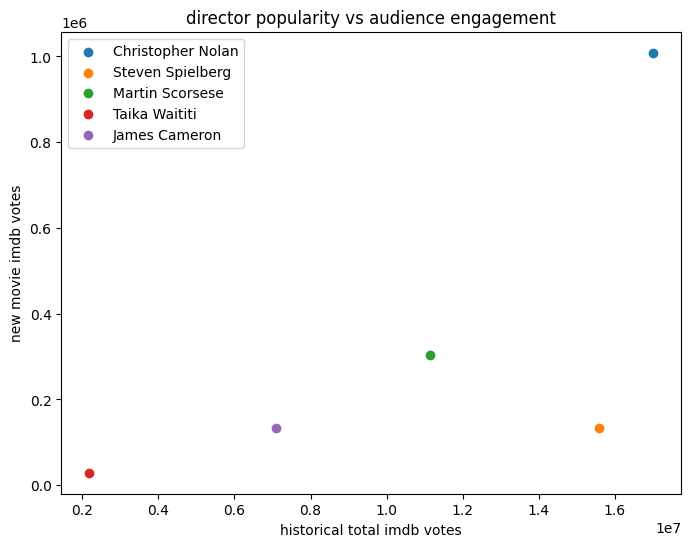

In [236]:
def popularity_scatter(csv):
    data = loading_data(csv)

    plt.figure(figsize=(8,6))


    for i, director in enumerate(data['director']):
        plt.scatter(data['hist_total_votes'][i], data['new_votes'][i],
                marker='o',
                label=director
                )


        plt.text(
            data['hist_total_votes'][i],
            data['new_votes'][i],
            ""
        )
        
    plt.xlabel('historical total imdb votes')
    plt.ylabel('new movie imdb votes')
    
    plt.title('director popularity vs audience engagement')

    plt.legend()
    plt.show()

popularity_scatter(csv)

In [ ]:
def load_and_clean_director_data(director_ids):

    data = {}

    for i in director_ids:
        df = pd.read_csv(f"director_{i}.csv")

        df = df.copy()
        df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
        df['avg_score'] = pd.to_numeric(df['avg_score'], errors='coerce')

        df = df.dropna(subset=['release_year','avg_score'])
        df = df.sort_values('release_year')

        data[i] = df

    return data

In [245]:
def plot_director_careers(director_ids, csv="director_list.csv"):
    
    csv = pd.read_csv(csv)

    data= loading_data(csv)

    dfs = load_and_clean_director_data(director_ids)

    plt.figure(figsize=(12,6))

    for director_id, df in dfs.items():
        
        plt.plot(
            df['release_year'],
            df['avg_score'],
            marker='o',
            label=data['director'][director_id]
        )
    
    plt.xlabel('release year')
    plt.ylabel('average score')

    plt.title('director career critical performance over time')

    plt.legend()

    plt.grid(True, alpha=0.3)
    
    plt.show()



In [ ]:
def director_over_time_plot(data):
    output = widgets.Output()
    director_ids = list(range(0,len(data)))

    checkboxes = [widgets.Checkbox(value=True, description=data['director'][i]) for i in director_ids]

    def update_plot(change=None):
    
        selected = [i for i, cb in enumerate(checkboxes) if cb.value]

        with output:
            clear_output(wait=True)

            if selected:
                plot_director_careers(selected)

    for cb in checkboxes:
        cb.observe(update_plot, names='value')

    display(widgets.VBox(checkboxes))
    display(output)

    update_plot()
director_over_time_plot(loading_data(csv))

Output()

In [263]:
def load_director_score_matrix(director_ids):
    data = loading_data(csv)

    dfs = []

    for i in director_ids:

        df = pd.read_csv(f'director_{i}.csv')

        df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
        df['avg_score'] = pd.to_numeric(df['avg_score'], errors='coerce')

        df = df.dropna(subset=['release_year', 'avg_score'])

        df['director_id'] = data['director'][i]

        dfs.append(df)
    combined = pd.concat(dfs)

    matrix = combined.pivot_table(
        index = 'director_id',
        columns = 'release_year',
        values = 'avg_score',
        aggfunc = 'mean'
    )
    return matrix

In [261]:
def plot_director_heatmap(director_ids):
    matrix = load_director_score_matrix(director_ids)
    
    plt.figure(figsize=(14,6))

    plt.imshow(matrix, aspect='auto', cmap='RdYlGn')

    plt.colorbar(label='average score')

    plt.yticks(
        range(len(matrix.index)),
        matrix.index
    )

    plt.xticks(
        range(len(matrix.columns)),
        matrix.columns,
        rotation=45
    )

    plt.tight_layout()
    plt.show()

In [265]:
def director_over_time_heatmap(data):
    output = widgets.Output()
    director_ids=list(range(len(data)))

    checkboxes = [widgets.Checkbox(value=True, description=data['director'][i]) for i in director_ids]

    def update_heatmap(change=None):

        selected = [i for i, cb in enumerate(checkboxes) if cb.value]

        with output:
            clear_output(wait=True)

            if selected:
                plot_director_heatmap(selected)
            else:
                print('select at least one director')

    for cb in checkboxes:
        cb.observe(update_heatmap, names = 'value')
    

    display(widgets.VBox(checkboxes))
    display(output)

    update_heatmap()

director_over_time_heatmap(loading_data(csv))

Output()

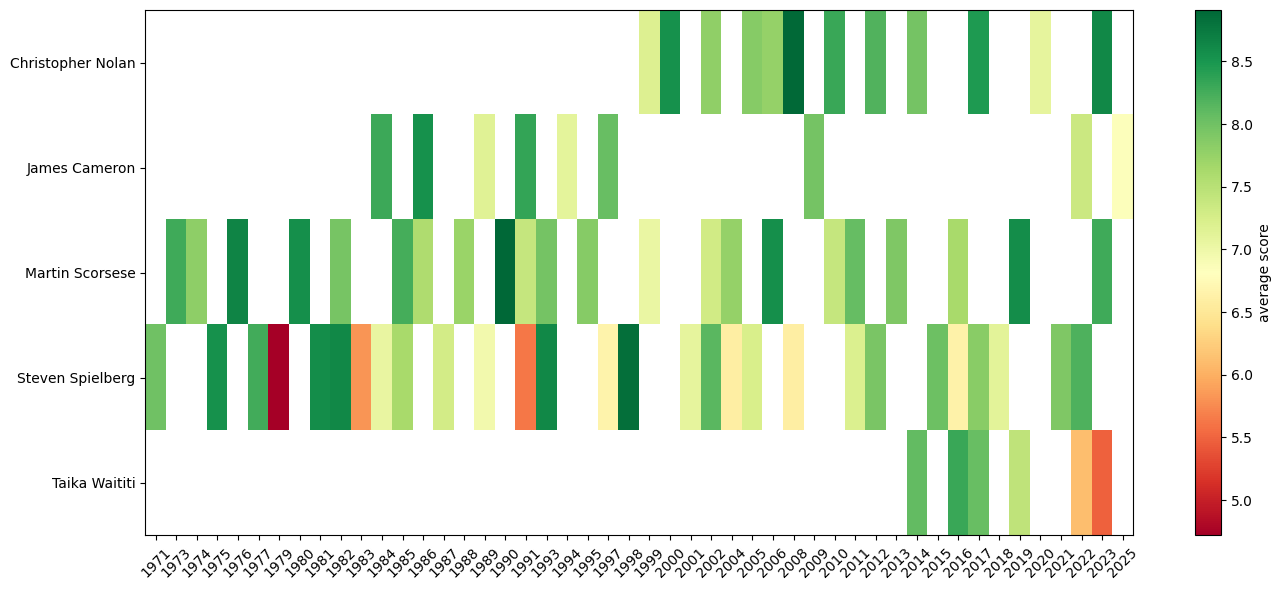

In [257]:
plot_director_heatmap(list(range(len(loading_data(csv)))))

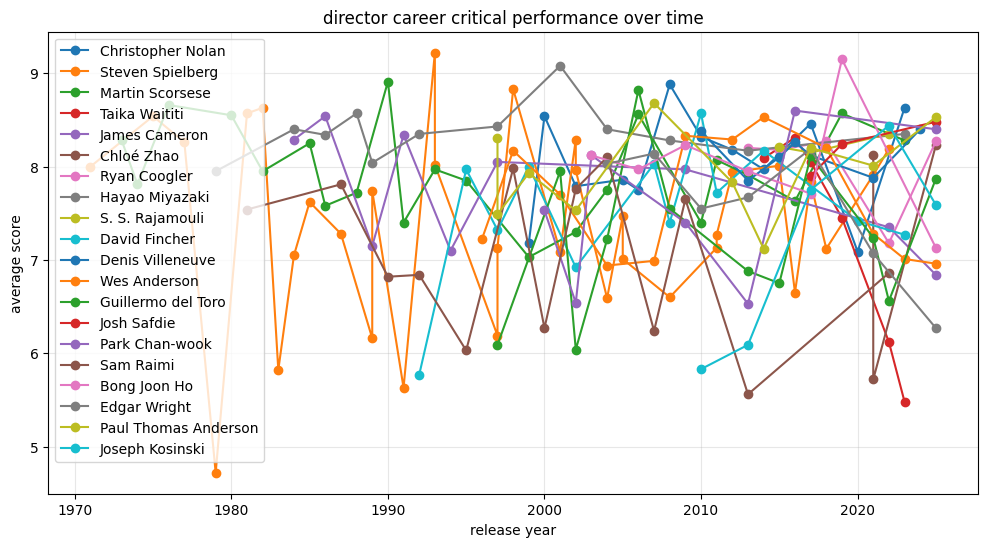

In [217]:
plot_director_careers(list(range(0,20)))


In [ ]:
director_colors = {
    0: "tab:grey",
    1: "tab:blue",
    2: "tab:orange",
    3: "tab:green",
    4: "tab:red",
    5: "tab:purple",
    6: "tab:brown",
    7: "tab:pink",
    8: "tab:gray",
    9: "tab:olive",
    10: "tab:cyan"
}

def load_budget_revenue_data(director_ids):
    
    dfs = []

    for i in director_ids:
        df = pd.read_csv(f'director_{i}.csv')

        df = df.copy()

        df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
        df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

        df = df.dropna(subset=['budget', 'revenue'])

        df['roi'] = df['revenue'] / df['budget']
        df['director_id'] = i
        
        df['name'] = data['director'][i]

        dfs.append(df)
    
    if len(dfs)==0:
        return pd.DataFrame()
    
    return pd.concat(dfs, ignore_index=True)


In [ ]:
def plot_budget_vs_revenue(director_ids,csv):
    csv = pd.read_csv(csv)
    data = loading_data(csv)

    df = load_budget_revenue_data(director_ids)

    if df.empty:
        print("no data to display")
        return
    
    plt.close('all')
    for id in director_ids:

        scatter = plt.scatter(
            df['budget'],
            df['revenue'],
            #c = df['color'],
            alpha=0.75,
            s = 70
        )
    
    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel('budget (log scale)')
    plt.ylabel('revenue (log scale)')
    plt.title('budget vs revenue (roi colored)')

    legend_elements = [
        Line2D(
            [0], [0],
            marker = 'o',
            color = 'w',
            label = data['director'][i],
            #markerfacecolor=director_colors[i],
            markersize=10
        )
        for i in director_ids
    ]

    plt.colorbar(scatter, label = "roi")

    plt.legend(handles=legend_elements)

    plt.grid(True, alpha=0.3)

    plt.show()

In [ ]:
director_ids = list(range(0,len(data)))


# dropdown = widgets.SelectMultiple(
#     options=[f"Director {i}" for i in director_ids],
#     value=[f"Director {i}" for i in director_ids],  # all selected initially
#     description="Directors",
#     rows=len(analysis_df)
# )

checkboxes = [
    widgets.Checkbox(value=True, description=data['director'][i])
    for i in director_ids
    ]
output = widgets.Output()

def update_scatter(change = None):
    
    selected = [i for i, cb in enumerate(checkboxes) if cb.value]
    #selected = [int(d.split()[1]) for d in dropdown.value]
    with output:
        clear_output(wait=True)

        if selected:
            plot_budget_vs_revenue(selected)
        else:
            print('select at least one director.')

for cb in checkboxes:
    cb.observe(update_scatter, "value")

display(widgets.VBox(checkboxes))
#display(dropdown)
display(output)

update_scatter()

Output()

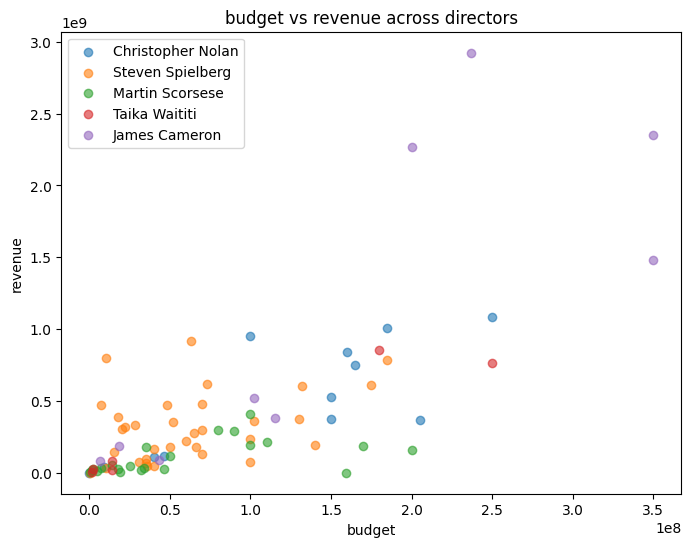

In [239]:
def budget_revenue(csv):
    data = loading_data(csv)
    plt.figure(figsize=(8,6))

    for i in range(0,len(data)):
        df = pd.read_csv(f'director_{i}.csv')

        plt.scatter(df['budget'], df['revenue'], alpha=0.6, label=data['director'][i])

    plt.xlabel('budget')
    plt.ylabel('revenue')
    plt.title('budget vs revenue across directors')

    plt.legend()
    plt.show()

budget_revenue(csv)

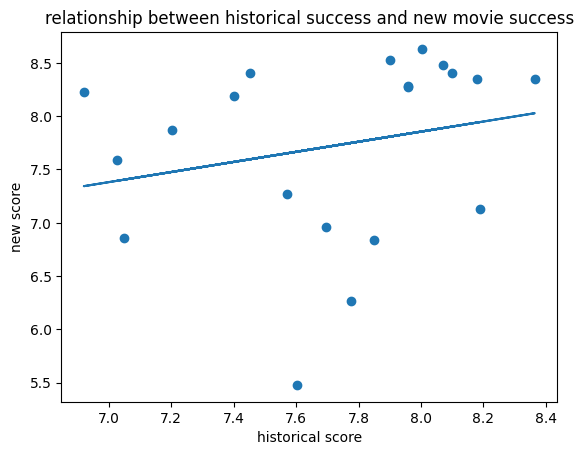

In [220]:
def historical_new_success(csv):
    data= loading_data(csv)
    x = data['hist_avg_score']
    y= data['new_score']

    m, b = np.polyfit(x,y,1)

    plt.scatter(x,y)    
    plt.plot(x, m*x + b)

    plt.xlabel('historical score')
    plt.ylabel('new score')
    plt.title('relationship between historical success and new movie success')

    plt.show

historical_new_success(csv)